In [11]:
from vmc_2024_02_28 import output_dir, get_config, get_lattice, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch

In [12]:
output_dir

PosixPath('experiments/vmc_2024_02_28')

In [13]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
)

/gpfs/home1/ishchurov/frustrations-eda/misc_utils.py:202: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dataframes).reset_index(drop=True)


In [14]:
df['task_id']

0        7.0
1        7.0
2        7.0
3        7.0
4        7.0
        ... 
22709    8.0
22710    8.0
22711    8.0
22712    8.0
22713    8.0
Name: task_id, Length: 22714, dtype: float64

In [15]:
df.columns

Index(['n_samples', 'lr', 'momentum', 'batch_size', 'sign_noise',
       'weight_decay', 'annealing_steps', 'initial_temp', 'max_iter',
       'sampling_mode', 'lattice', 'J2', 'use_symmetries', 'spin_inversion',
       'eval_set_max_size', 'save_predictions', 'device', 'random_seed',
       'force_numpy_sampling', 'log_prob_fn', 'n_hidden', 'hidden_layers',
       'overlap', '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'temp',
       'start_timestamp', 'task_id', 'prob_to_float64'],
      dtype='object')

In [16]:
df.query("task_id == 2")['start_timestamp'].value_counts()

start_timestamp
2024_03_04_16_15_17    1000
Name: count, dtype: int64

In [17]:
df.query("task_id >= 2")['lr'].unique()

array([0.01])

In [18]:
(df.query("task_id >= 2")
    .pipe(column_to(str, "task_id"))
    .assign(
        numpy_sampling=lambda df: df["force_numpy_sampling"]
        | (~df["random_seed"].isna())
    )).query('~numpy_sampling')['task_id'].unique()

array(['6.0', '5.0', '9.0'], dtype=object)

In [19]:
df.query("task_id >= 2")

,n_samples,lr,momentum,batch_size,sign_noise,weight_decay,annealing_steps,initial_temp,max_iter,sampling_mode,...,overlap,‖∇E‖₂,E_full_delta,ipr,step,E_variance,temp,start_timestamp,task_id,prob_to_float64
0,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.466657,0.648669,26.072214,3.849660e-07,0,0.000065,None,2024_03_04_19_46_45,7.0,False
1,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.596354,0.590945,12.383703,7.794354e-07,1,0.000059,None,2024_03_04_19_46_45,7.0,False
2,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.597058,0.522400,11.026474,8.037082e-06,2,0.000052,None,2024_03_04_19_46_45,7.0,False
3,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.637718,0.539107,13.369255,3.793512e-05,3,0.000054,None,2024_03_04_19_46_45,7.0,False
4,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.648550,0.514758,12.201649,2.895882e-05,4,0.000051,None,2024_03_04_19_46_45,7.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22709,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.640283,0.134816,1.242294,8.704661e-05,995,0.000013,None,2024_03_04_19_46_44,8.0,False
22710,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.639174,0.149662,1.063805,8.179372e-05,996,0.000015,None,2024_03_04_19_46_44,8.0,False
22711,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.638808,0.173423,1.105461,8.322981e-05,997,0.000017,None,2024_03_04_19_46_44,8.0,False
22712,10000,0.01,0.0,10000,0.0,0,0,3,1000,exact,...,0.639429,0.135510,1.095558,8.396830e-05,998,0.000014,None,2024_03_04_19_46_44,8.0,False


In [24]:
df.query("task_id == 9").iloc[0]

n_samples                             10000
lr                                     0.01
momentum                                0.0
batch_size                            10000
sign_noise                              0.0
weight_decay                              0
annealing_steps                           0
initial_temp                              3
max_iter                               1000
sampling_mode                         exact
lattice                           kagome2x4
J2                                        1
use_symmetries                        False
spin_inversion                         None
eval_set_max_size                     50000
save_predictions                       True
device                               cuda:0
random_seed                             NaN
force_numpy_sampling                  False
log_prob_fn              dense_pairwise_xor
n_hidden                                512
hidden_layers                             1
overlap                         

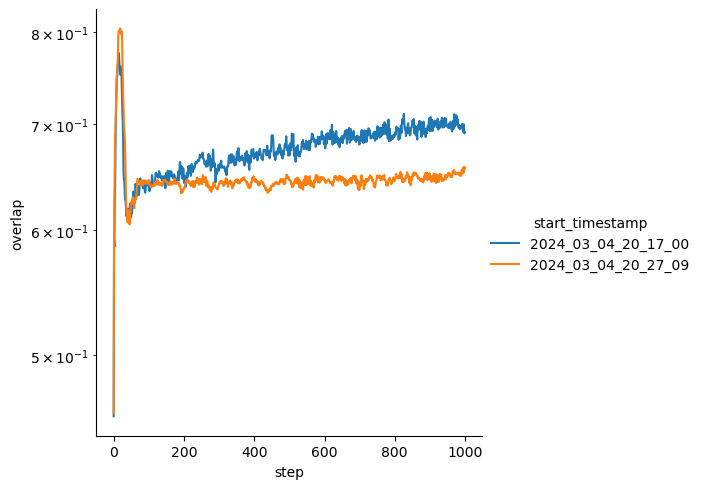

In [22]:
sns.relplot(
    df.query("task_id == 9")
    .pipe(column_to(str, "task_id"))
    .assign(
        numpy_sampling=lambda df: df["force_numpy_sampling"]
        | (~df["random_seed"].isna())
    ),
    x="step",
    y="overlap",
    kind="line",
    hue="start_timestamp",
   # style='task_id',
).set(yscale="log")

(array([2512., 2407., 2217., 2010., 1928., 1879., 1760., 1539., 1395.,
        1109.,  912.,  654.,  480.,  349.,  265.,  215.,  106.,   80.,
          51.,   14.]),
 array([-7.99994707, -7.69375753, -7.38756752, -7.08137798, -6.77518845,
        -6.46899843, -6.1628089 , -5.85661888, -5.55042934, -5.24423981,
        -4.93804979, -4.63186026, -4.32567024, -4.01948071, -3.71329117,
        -3.40710139, -3.10091162, -2.79472184, -2.48853207, -2.18234253,
        -1.87615275]),
 <BarContainer object of 20 artists>)

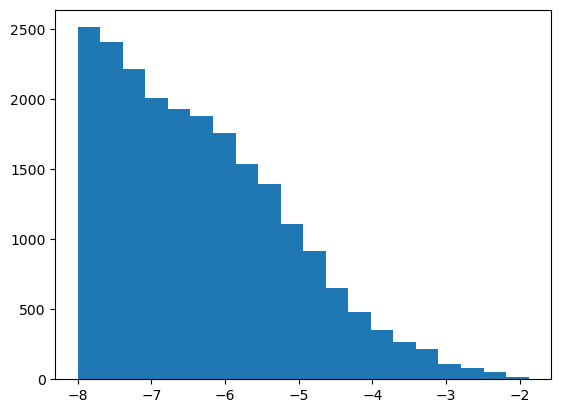

In [75]:
predicted_amplitudes = np.load(output_dir / "3" / "amplitudes_718.npy")
plt.hist(np.log10(predicted_amplitudes[(~np.isclose(predicted_amplitudes, 0))]), bins=20)

In [18]:
pred_delta = []
for i in range(1000):
    predictions = np.load(output_dir / "5" / f"predictions_{i}.npy")
    sorted_predictions = np.sort(predictions.flatten())
    pred_delta.append(sorted_predictions[-1] - sorted_predictions[-2])

In [ ]:
np.load(output_dir / "3" / f"predictions_{i}.npy")

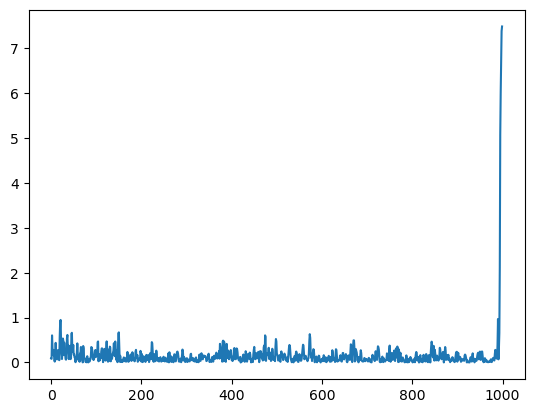

In [19]:
plt.plot(pred_delta)

(array([1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        3.000e+00, 0.000e+00, 3.000e+00, 6.000e+00, 8.000e+00, 1.500e+01,
        4.700e+01, 3.370e+02, 4.423e+03, 2.373e+03, 1.460e+02, 3.100e+01,
        1.700e+01, 7.000e+00, 4.000e+00, 2.000e+00, 2.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([0.80911308, 0.89806393, 0.98701479, 1.07596564, 1.1649165 ,
        1.25386735, 1.34281821, 1.43176906, 1.52071992, 1.60967077,
        1.69862163, 1.78757248, 1.87652334, 1.96547419, 2.05442505,
        2.1433759 , 2.23232676, 2.32127761, 2.41022847, 2.49917932,
        2.58813018, 2.67708103, 2.76603189, 2.85498274, 2.9439336 ,
        3.03288445, 3.12183531, 3.21

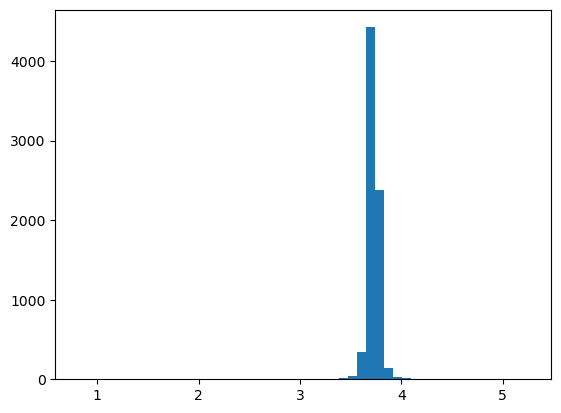

In [136]:
i = 300
log_E_loc = np.load(output_dir / "2" / f"log_E_loc_{i}.npy")
plt.hist(log_E_loc.real, bins=50)